# Generación de D114: Trial 4 de generación de sCMB siguiendo el pipeline de momeni en el dataset de CSIRO

Refinamiento de Precisión Clínica y Corrección de Sesgo de Dominio:
- Ajuste de Intensidad (Strength): Se restringe la distribución a $Triangular(0.85, 0.98, 1.0)$. Objetivo: Forzar la detección de vacíos de señal (blooming effect) y eliminar falsos positivos (FP) de intensidades medias/grises detectados en el Trial 3 ($I \approx 211$).
- Corrección Morfométrica (Elongación): Ajuste de radios de anisotropía a $rmin=0.8$ y $rmax=1.1$. Objetivo: Reducir la elongación sintética máxima hacia el rango de los TP reales ($0.25 - 0.49$) y penalizar estructuras tubulares (vasos) con elongación $>0.55$.
- Reequilibrio Anatómico: Modificación de pesos a Córtex (40%), White Matter (30%) y Deep Gray Matter (30%). Se incrementa la carga en DGM para mejorar la sensibilidad en núcleos profundos donde se detectaron Falsos Negativos (FN).
- Integridad de Etiquetas: Inclusión de etiquetas 3 y 42 (Córtex Cerebral) en el muestreo de SynthSeg, anteriormente omitidas.
- Dilatación de Interfase Córtex-LCR: Aplicación de una dilatación binaria (1 iteración) a la máscara cortical. Objetivo: Permitir la implantación de sCMBs en los surcos (sulci) para mitigar el 33% de FN clasificados erróneamente como CSF/Ventrículos.
- Rango de Volumen: Ajuste a $Triangular(1.2, 2.5, 10.0) \text{ mm}^3$ para asegurar coherencia con el blooming effect clínico de las microhemorragias en secuencias SWI.
- Umbral de Máscara (Ground Truth): Se mantiene en 0.3 para capturar la penumbra de la lesión, mejorando la segmentación de bordes por parte de la red (added by me).

In [9]:
import os
import glob
import numpy as np
import nibabel as nib
import json
from scipy.ndimage import binary_erosion, generate_binary_structure, rotate, binary_dilation
from skimage.transform import downscale_local_mean
import time
import shutil
from nilearn.image import resample_to_img

In [10]:
# ==========================================
# 1. CONFIGURACIÓN MASIVA (nnU-Net v2)
# ==========================================
# Ruta origen (AIBL limpio)
INPUT_ROOT_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/CSIRO_dataset/NoCMBSubject"
#INPUT_ROOT_DIR = r"C:\Users\marta\Downloads\NoCMBSubject"

# Ruta destino: IMPORTANTE usar formato DatasetXXX_Nombre
DATASET_NAME = "Dataset114_SyntheticCMB"
NNUNET_RAW_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/nnUNet_raw" 
#NNUNET_RAW_DIR = r"C:\Users\marta\Downloads\nnUNet_raw" 
OUTPUT_DIR = os.path.join(NNUNET_RAW_DIR, DATASET_NAME)

# Parámetros
RANDOM_SEED = 42

# Mantenemos la lógica de distribución de las sCMBs del Trial 3
TOTAL_SUBJECTS = 313
# 5% Limpios (), 50% con 8 sCMB (), 35% con 15 sCMB (), 10% con 20 sCMB ()
densities = [0]*15 + [10]*157 + [15]*110 + [20]*31 # Total: 3840 sCMBs

np.random.seed(RANDOM_SEED)
np.random.shuffle(densities) 

# Crear estructura de carpetas nnU-Net v2
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(os.path.join(OUTPUT_DIR, "imagesTr"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "labelsTr"), exist_ok=True)


In [15]:
# ==========================================
# 2. MOTOR MATEMÁTICO (Momeni Validado)
# ==========================================
def generate_momeni_gaussian(target_volume_mm3, voxel_size_mm, oversample=10):
    K = 1.175 
    term = (3 * target_volume_mm3) / (4 * np.pi * (K**3))
    sigma_t_mm = np.cbrt(term)
    
    # Aumentamos el rango de variación de los ejes para que no siempre sean casi-esferas
    rmin, rmax = 0.8, 1.1 # Acortamos rango
    sigma_x_mm = sigma_t_mm * np.random.uniform(rmin, rmax)
    sigma_y_mm = sigma_t_mm * np.random.uniform(rmin, rmax)
    # sigma_z se calcula para mantener el volumen constante, lo cual es correcto
    sigma_z_mm = (sigma_t_mm**3) / (sigma_x_mm * sigma_y_mm)

    hr_vx_size = np.array(voxel_size_mm) / oversample
    sx_px = sigma_x_mm / hr_vx_size[0]
    sy_px = sigma_y_mm / hr_vx_size[1]
    sz_px = sigma_z_mm / hr_vx_size[2]
    
    max_sigma = max(sx_px, sy_px, sz_px)
    grid_size = int(max_sigma * 5) + 1 # Lo subo de 4 a 5
    if grid_size % 2 == 0: grid_size += 1
    
    cx, cy, cz = grid_size // 2, grid_size // 2, grid_size // 2
    
    x = np.arange(grid_size) - cx
    y = np.arange(grid_size) - cy
    z = np.arange(grid_size) - cz
    xx, yy, zz = np.meshgrid(x, y, z, indexing='ij')
    
    exponent = - ( (xx**2)/(2*sx_px**2) + (yy**2)/(2*sy_px**2) + (zz**2)/(2*sz_px**2) )
    gaussian = np.exp(exponent)

    # MANTENEMOS CAMBIO PARA EL TRIAL 3: QUITAMOS EL HALF-THRESHOLDING 

    # MANTENEMOS CAMBIO PARA EL TRIAL 3: AÑADIMOS VARIABILIDAD AL SHARPENING
    exponent_val = np.random.uniform(1.0, 2.0)
    gaussian = gaussian**exponent_val
    
    angle_x = np.random.uniform(-30, 30)
    angle_y = np.random.uniform(-30, 30)
    angle_z = np.random.uniform(-30, 30)
    
    img_rot = rotate(gaussian, angle_x, axes=(0,1), reshape=False, order=1)
    img_rot = rotate(img_rot, angle_y, axes=(1,2), reshape=False, order=1)
    img_rot = rotate(img_rot, angle_z, axes=(0,2), reshape=False, order=1)
    
    low_res_blob = downscale_local_mean(img_rot, (oversample, oversample, oversample))
    if low_res_blob.max() > 0:
        low_res_blob /= low_res_blob.max()
        
    return low_res_blob



def implant_and_label(image_data, label_data, center, volume_mm3, voxel_dims, strength):
    x, y, z = center
    lesion_pattern = generate_momeni_gaussian(volume_mm3, voxel_dims, oversample=10)
    
    p_shape = lesion_pattern.shape
    dx, dy, dz = p_shape[0]//2, p_shape[1]//2, p_shape[2]//2
    x_s, x_e = x - dx, x - dx + p_shape[0]
    y_s, y_e = y - dy, y - dy + p_shape[1]
    z_s, z_e = z - dz, z - dz + p_shape[2]
    
    if x_s < 0 or x_e > image_data.shape[0] or \
       y_s < 0 or y_e > image_data.shape[1] or \
       z_s < 0 or z_e > image_data.shape[2]:
        return image_data, label_data
    
    roi_img = image_data[x_s:x_e, y_s:y_e, z_s:z_e]
    if roi_img.shape != lesion_pattern.shape:
        lesion_pattern = lesion_pattern[:roi_img.shape[0], :roi_img.shape[1], :roi_img.shape[2]]
    
    # Mantenemos Cambios Trial 2:
    mask_multiplier = 1 - (lesion_pattern * strength)
    mask_multiplier = np.clip(mask_multiplier, 0.02, 1.0)

    image_data[x_s:x_e, y_s:y_e, z_s:z_e] = roi_img * mask_multiplier
    
    roi_label = label_data[x_s:x_e, y_s:y_e, z_s:z_e]
    lesion_mask_binary = (lesion_pattern >= 0.3).astype(int) # MANTENEMOS CAMBIO TRIAL3: antes era 0.5 y hacía que cogiéramos sólo núcleo duro
    label_data[x_s:x_e, y_s:y_e, z_s:z_e] = np.maximum(roi_label, lesion_mask_binary)
    # 

    return image_data, label_data

def get_segmentation_sampling_mask(image_path, img_shape):
    """
    Localiza la segmentación de SynthSeg y genera un mapa de probabilidad
    basado en pesos anatómicos validados (55% Cortex, 35% WM, 10% Deep GM).
    Incluir resampling  espacial dado que SynthSeg resamplea a vóxeles 1x1x1mm.
    """
    # 1. Localización corregida del archivo de segmentación
    # image_path: .../NoCMBSubject/data/archivo.nii.gz
    data_dir = os.path.dirname(image_path)          # .../NoCMBSubject/data
    root_dir = os.path.dirname(data_dir)          # .../NoCMBSubject
    
    filename = os.path.basename(image_path)
    seg_name = filename.replace('.nii.gz', '_segmentation.nii.gz')
    seg_path = os.path.join(root_dir, "segmentations", seg_name)

    if not os.path.exists(seg_path):
        raise FileNotFoundError(f"No se encuentra la segmentación en: {seg_path}")

    # 2. Carga de objetos NIfTI
    img_nii = nib.load(image_path)
    seg_nii = nib.load(seg_path)

    # 3. RESAMPLING ESPACIAL EXACTO
    # 'interpolation=nearest' asegura que las etiquetas no se degraden
    seg_resampled_nii = resample_to_img(seg_nii, img_nii, interpolation='nearest')
    seg_data = seg_resampled_nii.get_fdata().astype(int)

    # Ahora seg_data.shape es EXACTAMENTE img_shape (176, 256, 80)
    # y la anatomía coincide milímetro a milímetro.

    # 3. Definición de etiquetas SynthSeg
    labels_wm = [2, 41]
    labels_dgm = [10, 49, 11, 50, 12, 51, 13, 52, 17, 53, 18, 54]
    labels_cortex = [3, 42] + list(range(1000, 3000)) # TRIAL 4: incluimos L y R cerebral cortex

    # CAMBIO TRIAL 4: Dilatación córtex para permitir que las lesiones se implanten en el borde
    # entre córtex y CSF
    # Creación de máscaras y dilatación:
    mask_wm = np.isin(seg_data, labels_wm)
    mask_dgm = np.isin(seg_data, labels_dgm)
    mask_cortex_raw = np.isin(seg_data, labels_cortex)
    mask_cortex = binary_dilation(mask_cortex_raw, iterations=1)
    
    # 4. Creación del mapa de pesos
    # Inicializamos con ceros (probabilidad 0 para CSF, hueso y fondo)
    weight_map = np.zeros(img_shape, dtype=float)

    # Asignación de pesos objetivos (distribución relativa)
    # CAMBIO TRIAL 4: incrementamos aún maś el DGM quitándole a los otros dos
    target_weights = {
        'cortex': 0.40,
        'wm': 0.30,
        'dgm': 0.30
    }
   
    # Para que la probabilidad total de una región sea el target_weight, 
    # cada vóxel individual debe tener (peso_objetivo / número_de_vóxeles)
    masks = [mask_cortex, mask_wm, mask_dgm]
    for mask, weight in zip(masks, target_weights.values()):
        n_voxels = np.sum(mask)
        if n_voxels > 0:
            weight_map[mask] = weight / n_voxels

    # 5. Obtener coordenadas y sus probabilidades
    valid_indices = np.argwhere(weight_map > 0)
    if len(valid_indices) == 0:
        return None, None
    # Extraemos las probabilidades de esos índices específicos
    probs = weight_map[weight_map > 0]
    
    # Normalización final por seguridad (debe sumar 1)
    probs /= probs.sum()

    return valid_indices, probs


### Ejecutamos y dividimos en dataset train y test con muestreo estratificado

In [16]:
# ==========================================
# 3. PREPARACIÓN ESTRATIFICADA Y EJECUCIÓN
# ==========================================
print(f"Iniciando Pipeline Trial 4...")
nifti_files = sorted(glob.glob(os.path.join(INPUT_ROOT_DIR, "data/*.nii.gz"), recursive=True))


# Configuración de estratos (Total 313)
# Grupo: [Cantidad Total, Cantidad Test] -> pasamos 33 a test con la misma proporción
estratos = {
    0:  [15, 2],   # Sanos
    10: [157, 17], # Moderados
    15: [110, 12],   # Severos
    20: [31, 2] # Graves
}

# Crear listas de densidad para Train y Test
train_pool = [0]*13 + [10]*140 + [15]*98 + [20]*29
test_pool  = [0]*2  + [10]*17  + [15]*12 + [20]*2

np.random.seed(RANDOM_SEED)
np.random.shuffle(train_pool)
np.random.shuffle(test_pool)

# Unimos: los primeros 280 son Train, los últimos 33 son Test
final_densities = train_pool + test_pool
final_splits = ["Tr"] * 280 + ["Ts"] * 33

# Crear carpetas necesarias
for folder in ["imagesTr", "labelsTr", "imagesTs", "labelsTs"]:
    os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)

# --- BUCLE DE GENERACIÓN ---
for idx, file_path in enumerate(nifti_files):
    num_lesions = final_densities[idx]
    split = final_splits[idx]
    subject_id = f"CSIRO_{idx+1:03d}"
    
    print(f"[{idx+1}/313] {subject_id} | Objetivo: {num_lesions} sCMB | Destino: {split}")
    
    try:
        nii = nib.load(file_path)
        data_img = nii.get_fdata().astype(float)
        data_label = np.zeros(data_img.shape, dtype=np.uint8)
        voxel_dims = nii.header.get_zooms()

        if num_lesions > 0:
            valid_coords, probs = get_segmentation_sampling_mask(file_path, data_img.shape)
            if valid_coords is not None:
                random_indices = np.random.choice(len(valid_coords), size=num_lesions, replace=False, p=probs)
                for coord in valid_coords[random_indices]:
                    vol_rnd = np.random.triangular(1.2, 2.5, 10.0) # Trial 4: reducimos un poco volumen máximo
                    str_rnd = np.random.triangular(0.85, 0.98, 1.0) # Trial 4: CORRECCIÓN! Las estaba haciendo muy claras, cambiar hacia oscuro
                    data_img, data_label = implant_and_label(data_img, data_label, coord, vol_rnd, voxel_dims, str_rnd)

        # Guardado Directo
        img_ext = "_0000.nii.gz"
        nib.save(nib.Nifti1Image(data_img, nii.affine, nii.header), 
                 os.path.join(OUTPUT_DIR, f"images{split}", f"{subject_id}{img_ext}"))
        nib.save(nib.Nifti1Image(data_label, nii.affine, nii.header), 
                 os.path.join(OUTPUT_DIR, f"labels{split}", f"{subject_id}.nii.gz"))
        
    except Exception as e:
        print(f"    ERROR en {subject_id}: {e}")

# ==========================================
# 4. DATASET.JSON AUTOMÁTICO
# ==========================================
json_dict = {
    "channel_names": {"0": "SWI"},
    "labels": {"background": 0, "CMB": 1},
    "numTraining": 280,
    "file_ending": ".nii.gz",
    "name": DATASET_NAME,
    "reference": "Momeni Variant Method (Stratified Trial 4)",
    "description": "10% Healthy, 50% 10 sCMB, 35% 15 sCMB, 15% 20 sCMB. Integrated anatomical weights.",
    "overwrite_image_reader_writer": "SimpleITKIO"
}

with open(os.path.join(OUTPUT_DIR, "dataset.json"), 'w') as f:
    json.dump(json_dict, f, indent=4)

print(f"\nDATASET LISTO: {len(train_pool)} Entrenamiento / {len(test_pool)} Test")

Iniciando Pipeline Trial 4...
[1/313] CSIRO_001 | Objetivo: 10 sCMB | Destino: Tr
[2/313] CSIRO_002 | Objetivo: 10 sCMB | Destino: Tr
[3/313] CSIRO_003 | Objetivo: 15 sCMB | Destino: Tr
[4/313] CSIRO_004 | Objetivo: 20 sCMB | Destino: Tr
[5/313] CSIRO_005 | Objetivo: 15 sCMB | Destino: Tr
[6/313] CSIRO_006 | Objetivo: 0 sCMB | Destino: Tr
[7/313] CSIRO_007 | Objetivo: 10 sCMB | Destino: Tr
[8/313] CSIRO_008 | Objetivo: 15 sCMB | Destino: Tr
[9/313] CSIRO_009 | Objetivo: 10 sCMB | Destino: Tr
[10/313] CSIRO_010 | Objetivo: 15 sCMB | Destino: Tr
[11/313] CSIRO_011 | Objetivo: 15 sCMB | Destino: Tr
[12/313] CSIRO_012 | Objetivo: 10 sCMB | Destino: Tr
[13/313] CSIRO_013 | Objetivo: 15 sCMB | Destino: Tr
[14/313] CSIRO_014 | Objetivo: 15 sCMB | Destino: Tr
[15/313] CSIRO_015 | Objetivo: 10 sCMB | Destino: Tr
[16/313] CSIRO_016 | Objetivo: 15 sCMB | Destino: Tr
[17/313] CSIRO_017 | Objetivo: 10 sCMB | Destino: Tr
[18/313] CSIRO_018 | Objetivo: 10 sCMB | Destino: Tr
[19/313] CSIRO_019 | Objet

###  Comparativa ressolución imágenes originales con la segmentación de synthseg para estudiar el resampling

In [26]:
import os
import glob
import nibabel as nib
import pandas as pd

# --- CONFIGURACIÓN DE RUTAS ---
DATA_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/CSIRO_dataset/NoCMBSubject/data"
SEG_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/CSIRO_dataset/NoCMBSubject/segmentations"

results = []

nifti_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.nii.gz")))

print(f"Auditando {len(nifti_files)} pares de archivos...")

for f in nifti_files:
    fname = os.path.basename(f)
    sname = fname.replace('.nii.gz', '_segmentation.nii.gz')
    spath = os.path.join(SEG_DIR, sname)
    
    if not os.path.exists(spath):
        continue
        
    img_nii = nib.load(f)
    seg_nii = nib.load(spath)
    
    results.append({
        'Sujeto': fname,
        'SWI_Shape': img_nii.shape,
        'Seg_Shape': seg_nii.shape,
        'SWI_Voxel_mm': tuple(np.round(img_nii.header.get_zooms(), 2)),
        'Seg_Voxel_mm': tuple(np.round(seg_nii.header.get_zooms(), 2)),
        'Diff_Shape': img_nii.shape != seg_nii.shape
    })

df = pd.DataFrame(results)

# Resumen estadístico
diff_count = df['Diff_Shape'].sum()
print(f"\n--- RESULTADOS DEL ANÁLISIS ---")
print(f"Total analizados: {len(df)}")
print(f"Sujetos con discrepancia de dimensiones: {diff_count} ({diff_count/len(df)*100:.1f}%)")

# Mostrar los primeros 10 para inspección rápida
print("\nMuestra de los primeros 10 casos:")
print(df[['Sujeto', 'SWI_Shape', 'Seg_Shape', 'SWI_Voxel_mm', 'Seg_Voxel_mm']].head(10).to_string(index=False))

# Guardar a CSV para tu TFM
df.to_csv("/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/CSIRO_dataset/NoCMBSubject/auditoria_synthseg_resoluciones_trial2.csv", index=False)

Auditando 313 pares de archivos...

--- RESULTADOS DEL ANÁLISIS ---
Total analizados: 313
Sujetos con discrepancia de dimensiones: 313 (100.0%)

Muestra de los primeros 10 casos:
                           Sujeto      SWI_Shape       Seg_Shape       SWI_Voxel_mm    Seg_Voxel_mm
101_T1_MRI_SWI_BFC_50mm_HM.nii.gz (176, 256, 80) (165, 241, 140) (0.94, 0.94, 1.75) (1.0, 1.0, 1.0)
102_T1_MRI_SWI_BFC_50mm_HM.nii.gz (176, 256, 80) (165, 241, 140) (0.94, 0.94, 1.75) (1.0, 1.0, 1.0)
108_T1_MRI_SWI_BFC_50mm_HM.nii.gz (176, 256, 80) (165, 241, 140) (0.94, 0.94, 1.75) (1.0, 1.0, 1.0)
110_T1_MRI_SWI_BFC_50mm_HM.nii.gz (176, 256, 80) (166, 241, 140) (0.94, 0.94, 1.75) (1.0, 1.0, 1.0)
115_T1_MRI_SWI_BFC_50mm_HM.nii.gz (176, 256, 80) (165, 242, 141) (0.94, 0.94, 1.75) (1.0, 1.0, 1.0)
124_T1_MRI_SWI_BFC_50mm_HM.nii.gz (176, 256, 80) (165, 240, 140) (0.94, 0.94, 1.75) (1.0, 1.0, 1.0)
124_T2_MRI_SWI_BFC_50mm_HM.nii.gz (176, 256, 80) (165, 240, 141) (0.94, 0.94, 1.75) (1.0, 1.0, 1.0)
124_T3_MRI_SWI_BFC_50

## Visualización


Caso: CSIRO_274 | Lesión en (np.int64(62), np.int64(114), np.int64(68))


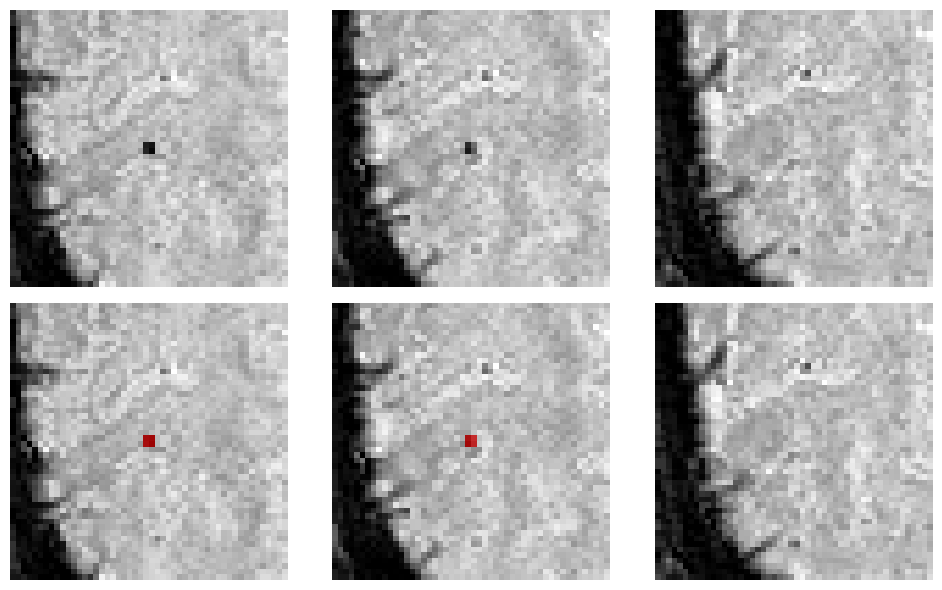


Caso: CSIRO_148 | Lesión en (np.int64(78), np.int64(215), np.int64(45))


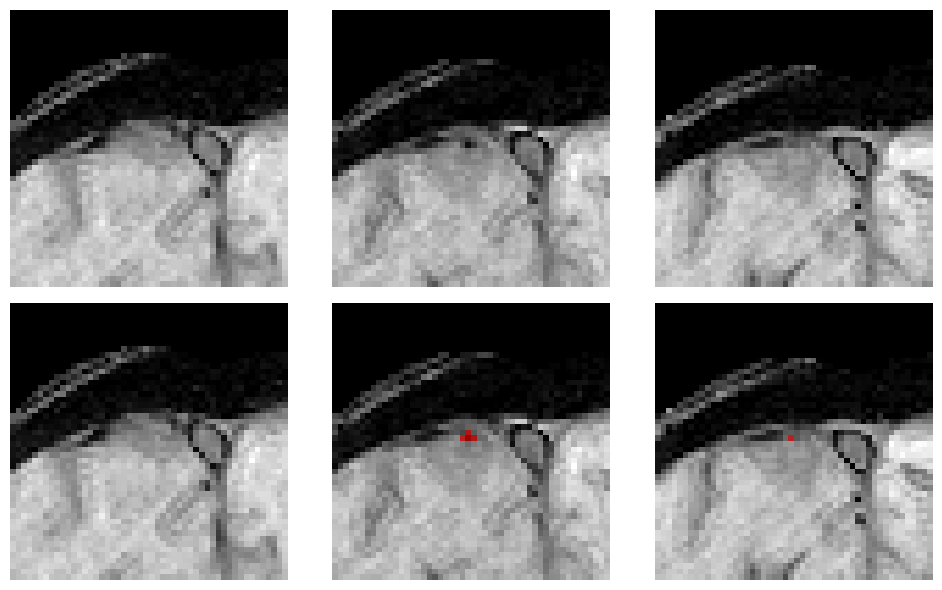


Caso: CSIRO_005 | Lesión en (np.int64(58), np.int64(62), np.int64(48))


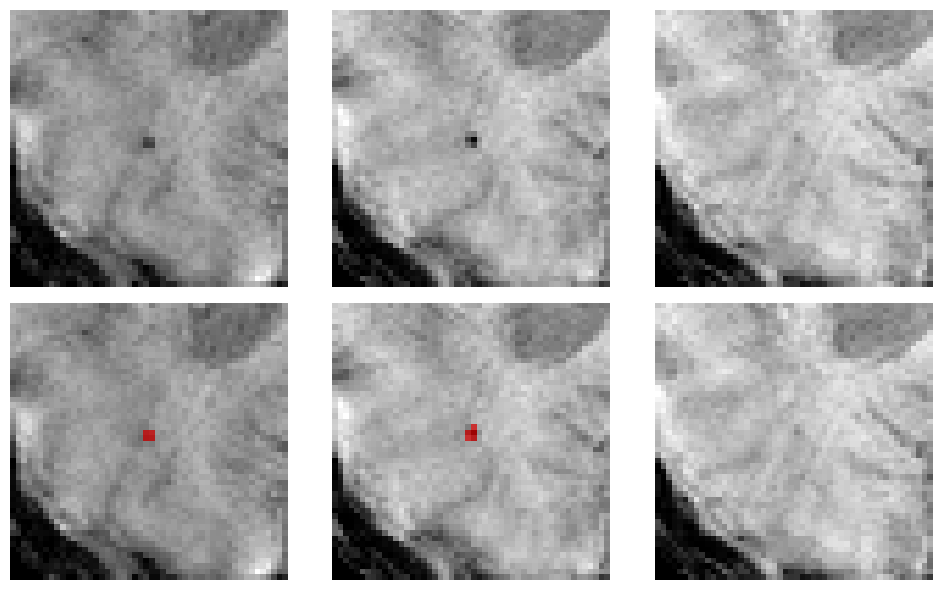


Caso: CSIRO_207 | Lesión en (np.int64(55), np.int64(119), np.int64(36))


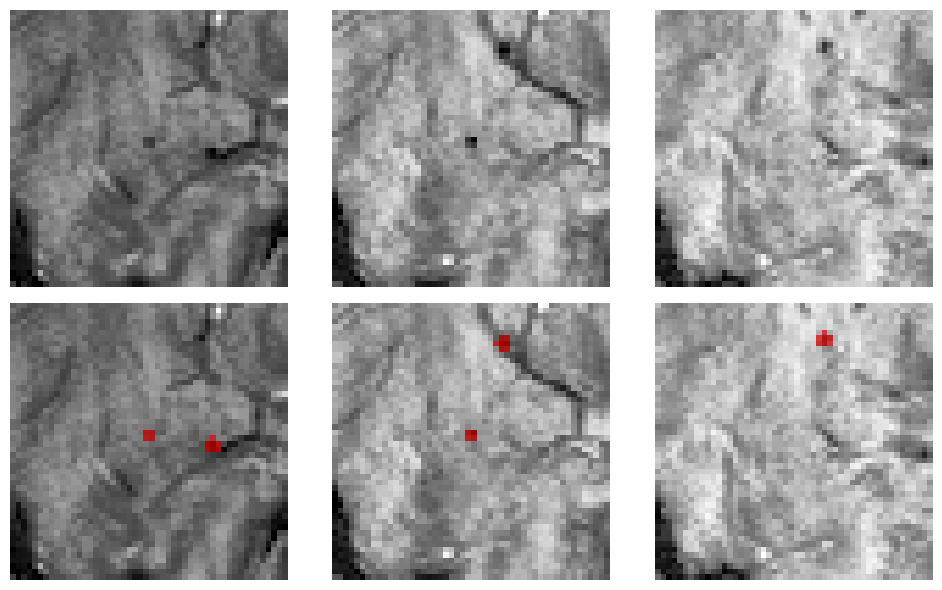


Caso: CSIRO_208 | Lesión en (np.int64(131), np.int64(153), np.int64(46))


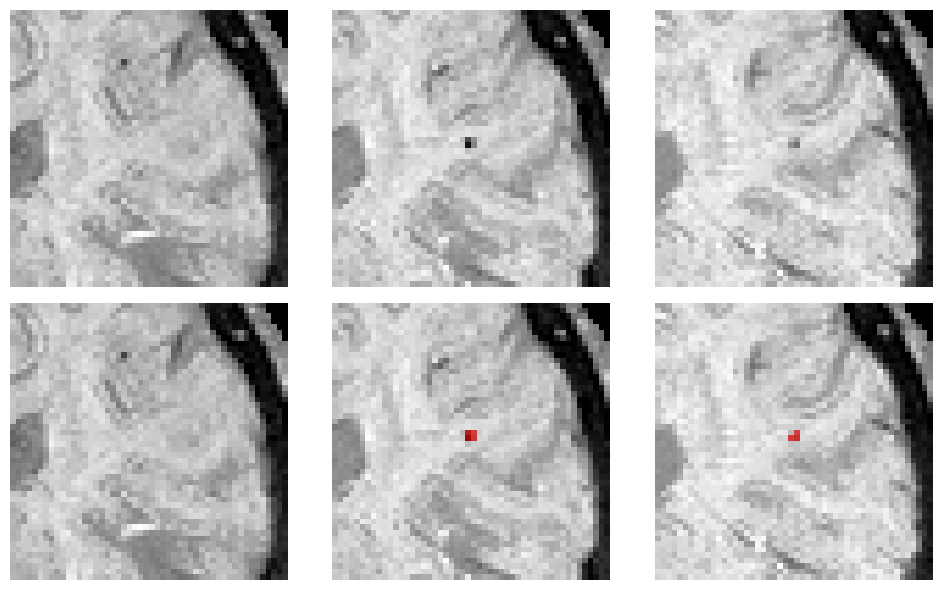


Caso: CSIRO_059 | Lesión en (np.int64(71), np.int64(139), np.int64(41))


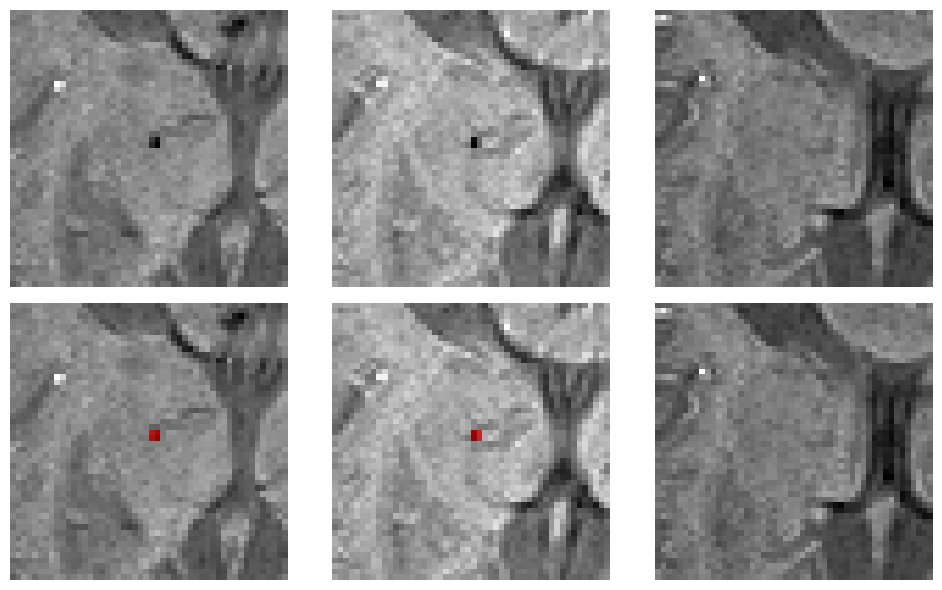


Caso: CSIRO_162 | Lesión en (np.int64(63), np.int64(77), np.int64(41))


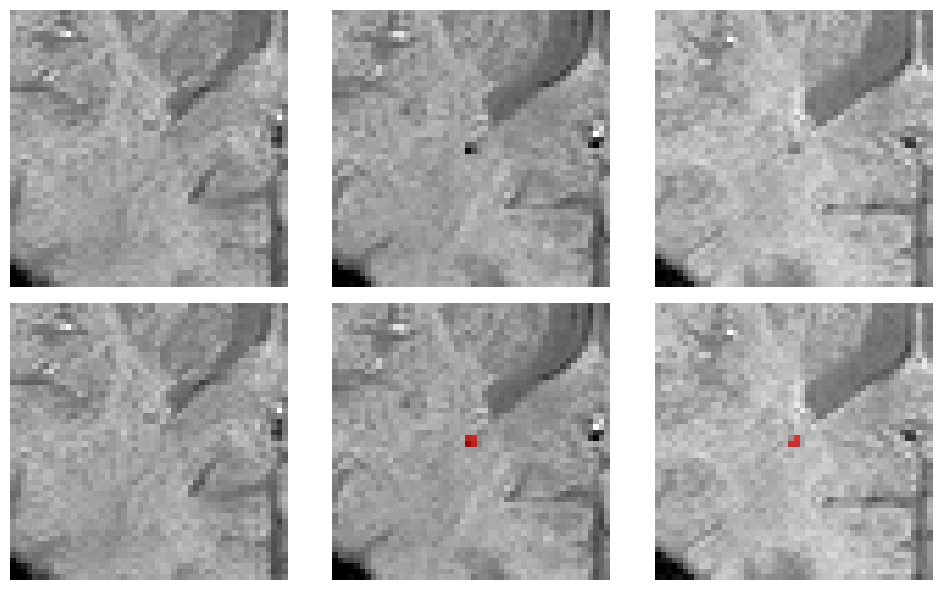


Caso: CSIRO_009 | Lesión en (np.int64(81), np.int64(131), np.int64(42))


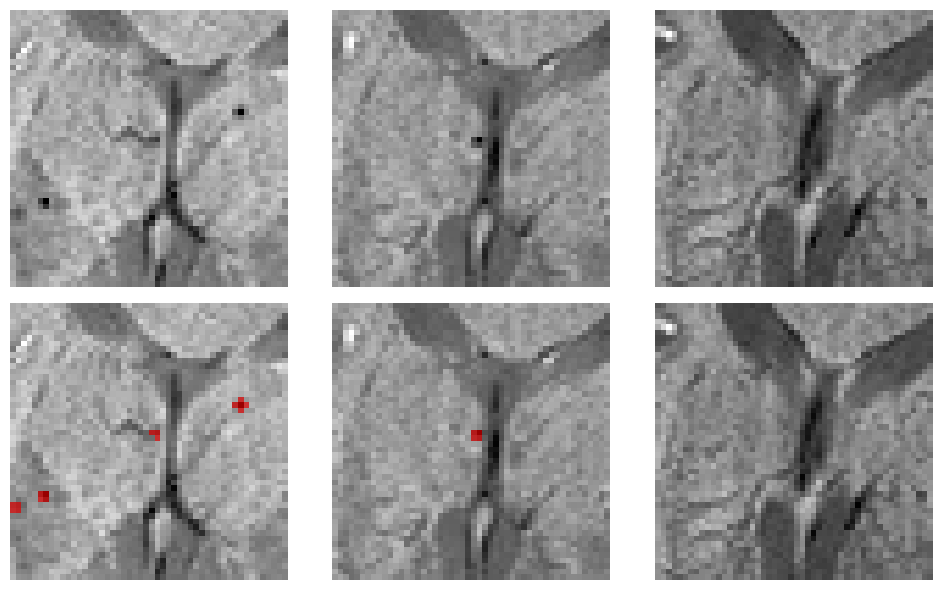


Caso: CSIRO_178 | Lesión en (np.int64(28), np.int64(169), np.int64(39))


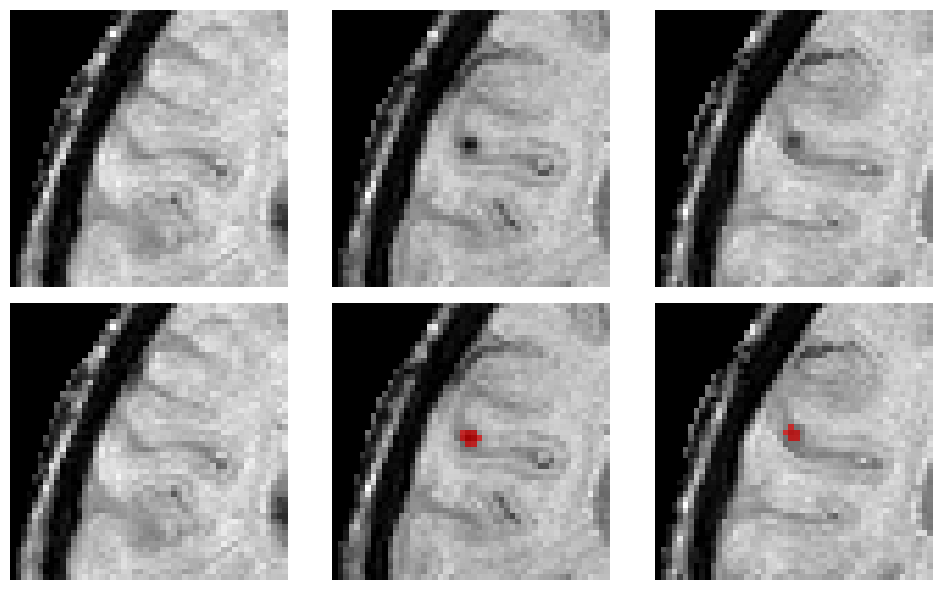


Caso: CSIRO_111 | Lesión en (np.int64(117), np.int64(95), np.int64(38))


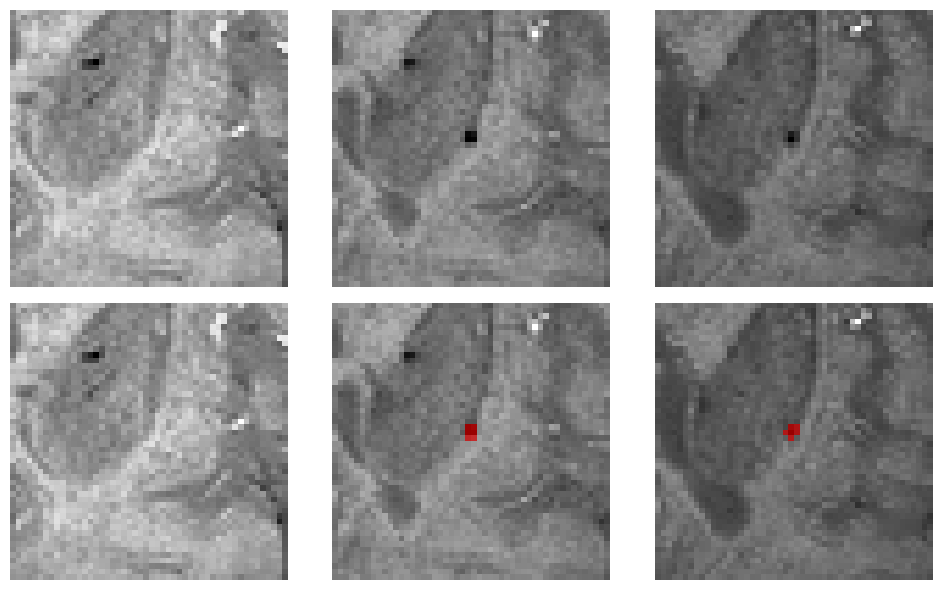


Caso: CSIRO_004 | Lesión en (np.int64(112), np.int64(118), np.int64(46))


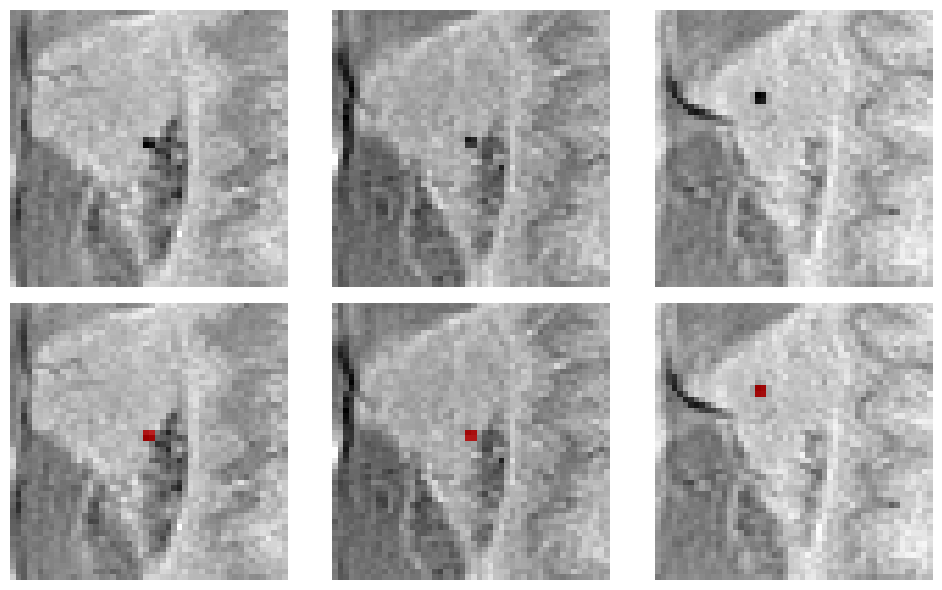


Caso: CSIRO_031 | Lesión en (np.int64(114), np.int64(118), np.int64(27))


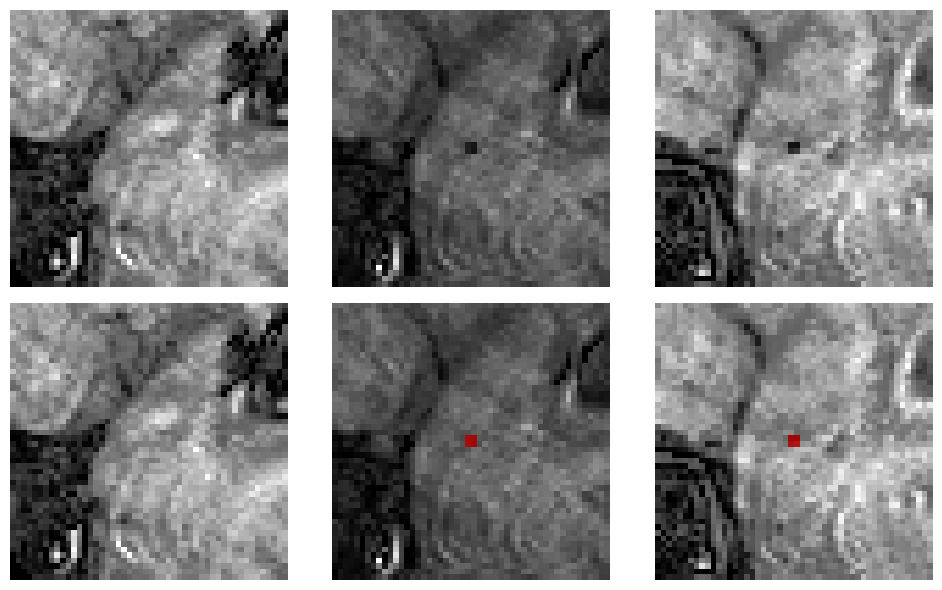


Caso: CSIRO_106 | Lesión en (np.int64(80), np.int64(165), np.int64(59))


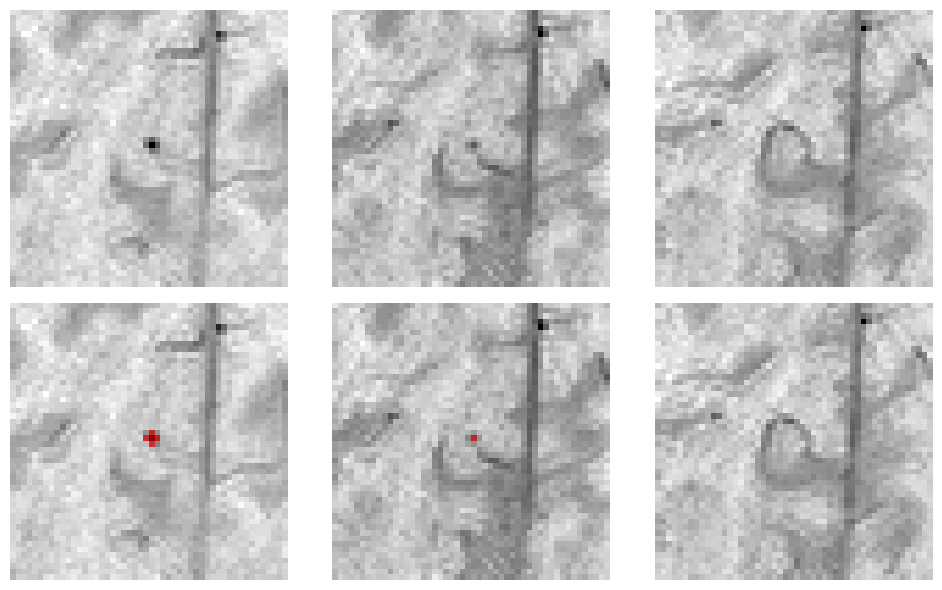


Caso: CSIRO_218 | Lesión en (np.int64(108), np.int64(159), np.int64(61))


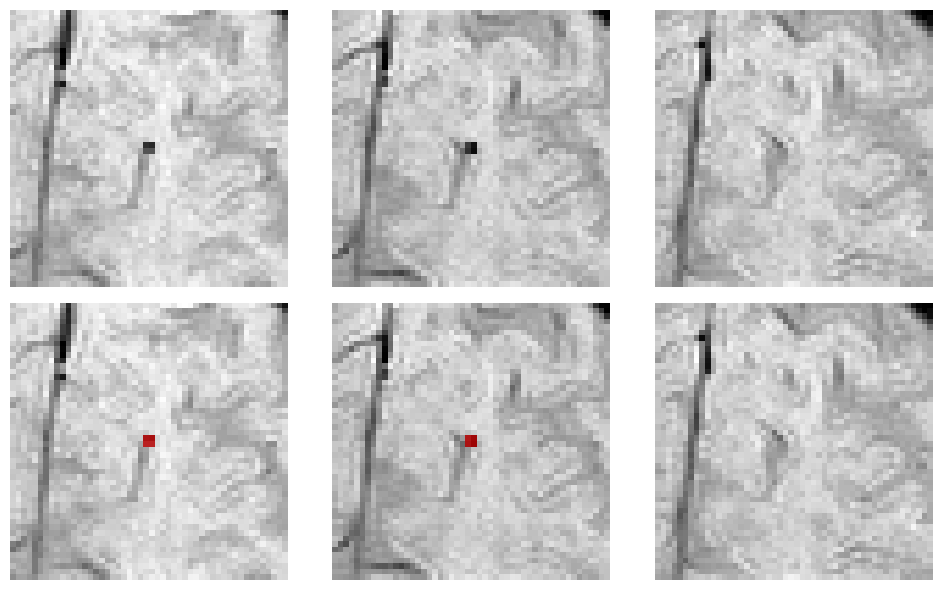


Caso: CSIRO_172 | Lesión en (np.int64(29), np.int64(156), np.int64(21))


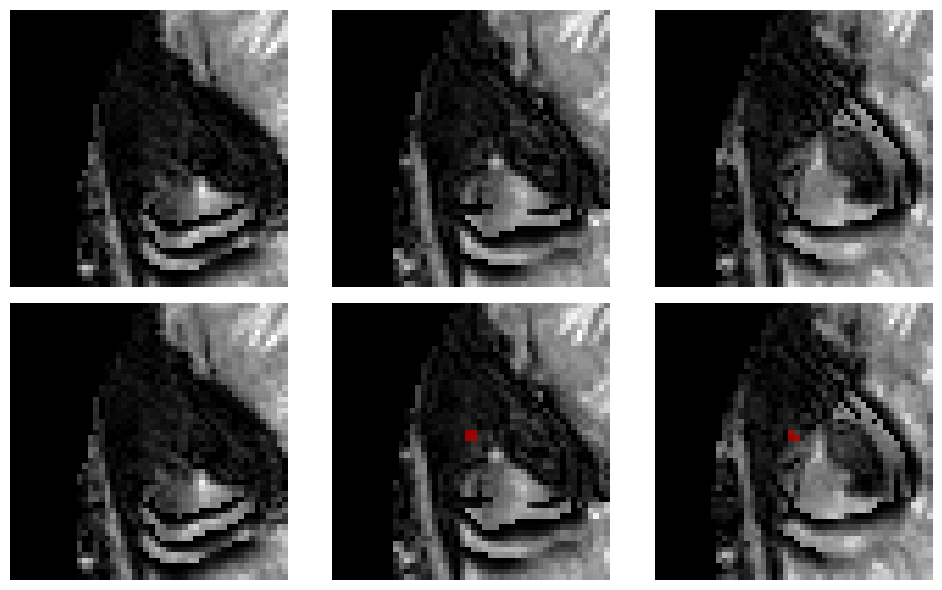

In [4]:
import os
import random
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# Ruta al dataset generado
OUTPUT_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/nnUNet_raw/Dataset114_SyntheticCMB" 
DATASET_PATH = OUTPUT_DIR  # ya definida en tu script

def get_random_lesion_bbox(label):
    coords = np.array(np.where(label > 0))
    
    if coords.shape[1] == 0:
        return None
    
    # Elegimos una lesión aleatoria
    idx = np.random.randint(coords.shape[1])
    x, y, z = coords[:, idx]
    
    return x, y, z


def crop_zoom_exact(img, lbl, center, window=25):
    cx, cy, cz = map(int, center)
    
    x_s, x_e = max(0, cx-window), min(img.shape[0], cx+window)
    y_s, y_e = max(0, cy-window), min(img.shape[1], cy+window)
    
    img_crop = img[x_s:x_e, y_s:y_e, :]
    lbl_crop = lbl[x_s:x_e, y_s:y_e, :]
    
    return img_crop, lbl_crop


def normalize(patch):
    return (patch - np.min(patch)) / (np.max(patch) - np.min(patch) + 1e-8)


def plot_triplet_exact(img_crop, lbl_crop, z_center):
    slices = [z_center-1, z_center, z_center+1]
    
    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    
    for i, z in enumerate(slices):
        if z < 0 or z >= img_crop.shape[2]:
            continue
        
        img_slice = normalize(img_crop[:, :, z])
        lbl_slice = lbl_crop[:, :, z]
        
        # 🔹 SOLO IMAGEN (igual que tu pipeline)
        axes[0, i].imshow(np.rot90(img_slice), cmap='gray')
        axes[0, i].axis('off')
        
        # 🔹 IMAGEN + MÁSCARA
        axes[1, i].imshow(np.rot90(img_slice), cmap='gray')
        axes[1, i].imshow(
            np.ma.masked_where(np.rot90(lbl_slice) == 0, np.rot90(lbl_slice)),
            cmap='autumn',
            alpha=0.6
        )
        axes[1, i].axis('off')
    
    axes[0, 0].set_ylabel("Imagen", fontsize=12)
    axes[1, 0].set_ylabel("Imagen + Mask", fontsize=12)
    
    plt.tight_layout()
    plt.show()

def show_zoom_example(split="Tr"):
    images_dir = os.path.join(DATASET_PATH, f"images{split}")
    labels_dir = os.path.join(DATASET_PATH, f"labels{split}")
    
    cases = sorted([f for f in os.listdir(images_dir) if f.endswith("_0000.nii.gz")])
    
    while True:
        case = random.choice(cases)
        subject_id = case.replace("_0000.nii.gz", "")
        
        img_path = os.path.join(images_dir, case)
        lbl_path = os.path.join(labels_dir, f"{subject_id}.nii.gz")
        
        nii_img = nib.load(img_path)
        nii_lbl = nib.load(lbl_path)
        
        img = nii_img.get_fdata()
        lbl = nii_lbl.get_fdata()
        
        center = get_random_lesion_bbox(lbl)
        
        if center is None:
            continue  # saltar casos sin lesión
        
        print(f"\nCaso: {subject_id} | Lesión en {center}")

        img_crop, lbl_crop = crop_zoom_exact(img, lbl, center, window=25)
        
        # Ajustar z al nuevo sistema
        z_center = center[2]
        
        plot_triplet_exact(img_crop, lbl_crop, z_center)
        break

# ==========================
# EJECUCIÓN
# ==========================
for _ in range(15):
    show_zoom_example(split="Tr")